# Modeling with the KNN-imputed dataset
In this notebook, we will test out various models on the dataset with SMOTENC and k-Nearest Neighbors imputation applied.

The models being tested will be split up into two camps: scale sensitive and scale insensitive

Their performance will be evaluated on the following metrics:
- K-Fold Cross-Validation (recall, ROC-AUC)
- score
- train & test recall
- confusion matrix
- train & test ROC-AUC

In [8]:
# Import libraries
import pandas as pd
import numpy as np

# Import dataset
df = pd.read_csv('../data/smotenc_knn_df.csv') # k-Nearest Neighbors imputed dataset with SMOTENC
df.head()

,male,age,cigsPerDay,BPMeds,prevalentHyp,totChol,BMI,heartRate,glucose,MAP,TenYearCHD
0,0.0,53.0,20.0,0.0,0.0,221.0,24.09,90.0,95.0,103.0,0
1,0.0,64.0,6.0,0.0,1.0,239.0,20.06,55.0,73.0,103.7,0
2,0.0,38.0,0.0,0.0,0.0,185.0,22.15,85.0,83.0,81.3,0
3,0.0,49.0,0.0,0.0,0.0,270.0,26.56,70.0,77.0,87.2,0
4,1.0,56.0,20.0,0.0,0.0,186.0,24.62,70.0,83.0,83.3,0


In [9]:
# Import train, test, split
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns='TenYearCHD')
y = df['TenYearCHD']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Import libraries

import xgboost as xgb # Scale insensitive
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression # Scale sensitive
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Dictionary of scale insensitive models
scale_ins_models = {
    'XGBoost': xgb.XGBClassifier(),
    'Gradient Boosting' : GradientBoostingClassifier(),
    'Random Forest' : RandomForestClassifier(random_state=42)
}

# Dictionary of scale sensitive models
scale_sens_models = {
    'k-Nearest Neighbors': KNeighborsClassifier(n_neighbors=8),
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'SVC' : SVC()
}

# Scale Insensitive Models



--Evaluating XGBoost--

Cross-Validation Results:
Recall: 0.86, ROC-AUC: 0.94 +- 0.005

Score: 0.89
Training Recall: 0.99
Test Recall: 0.87

Classification Report:
              precision  recall  f1-score  support
0                  0.87    0.91      0.89   577.00
1                  0.90    0.87      0.88   572.00
accuracy           0.89    0.89      0.89     0.89
macro avg          0.89    0.89      0.89  1149.00
weighted avg       0.89    0.89      0.89  1149.00


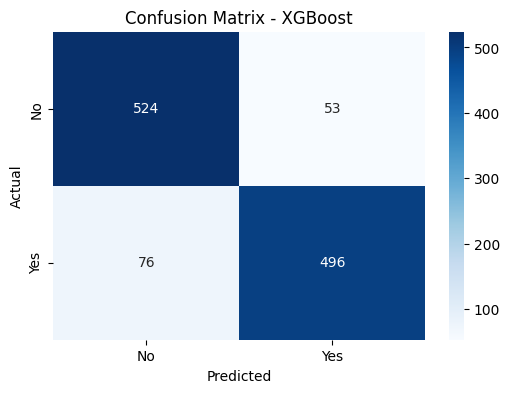

Test ROC-AUC: 0.95
Train ROC-AUC: 1.00



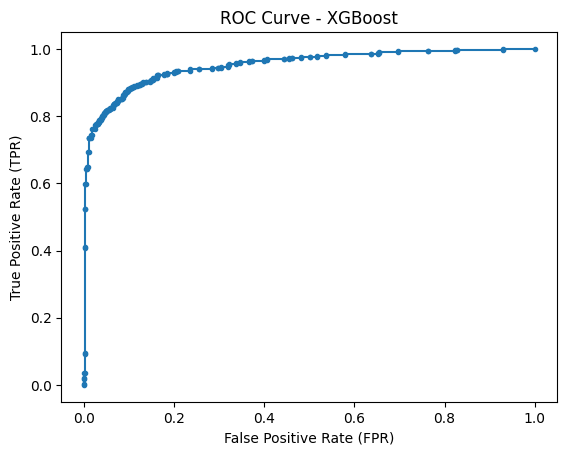

False Positive Rate (FPR): 0.000


--Evaluating Gradient Boosting--

Cross-Validation Results:
Recall: 0.82, ROC-AUC: 0.89 +- 0.013

Score: 0.82
Training Recall: 0.85
Test Recall: 0.83

Classification Report:
              precision  recall  f1-score  support
0                  0.83    0.82      0.82   577.00
1                  0.82    0.83      0.82   572.00
accuracy           0.82    0.82      0.82     0.82
macro avg          0.82    0.82      0.82  1149.00
weighted avg       0.82    0.82      0.82  1149.00


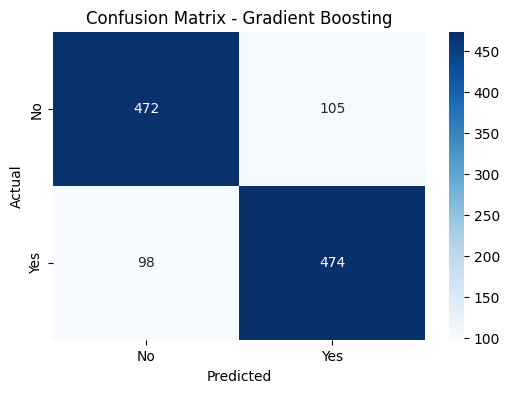

Test ROC-AUC: 0.90
Train ROC-AUC: 0.93



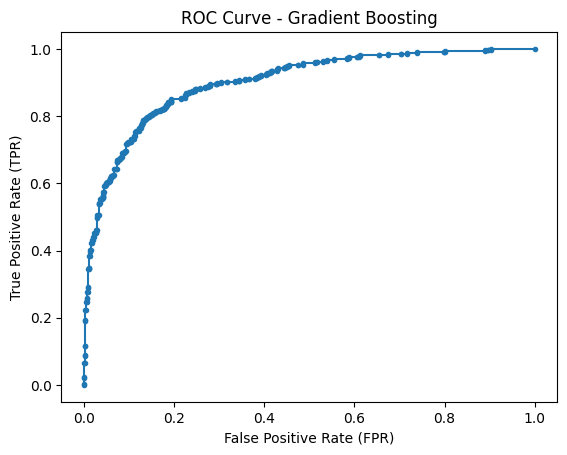

False Positive Rate (FPR): 0.000


--Evaluating Random Forest--

Cross-Validation Results:
Recall: 0.88, ROC-AUC: 0.94 +- 0.003

Score: 0.88
Training Recall: 1.00
Test Recall: 0.92

Classification Report:
              precision  recall  f1-score  support
0                  0.91    0.84      0.87   577.00
1                  0.85    0.92      0.88   572.00
accuracy           0.88    0.88      0.88     0.88
macro avg          0.88    0.88      0.88  1149.00
weighted avg       0.88    0.88      0.88  1149.00


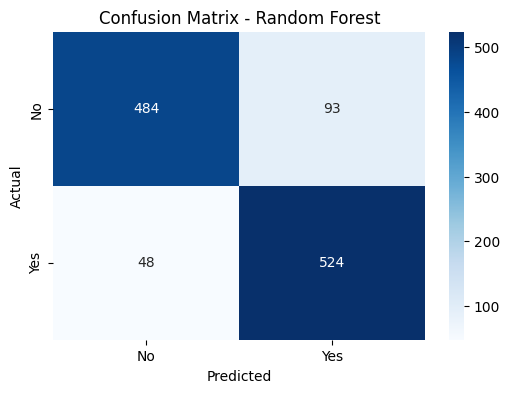

Test ROC-AUC: 0.96
Train ROC-AUC: 1.00



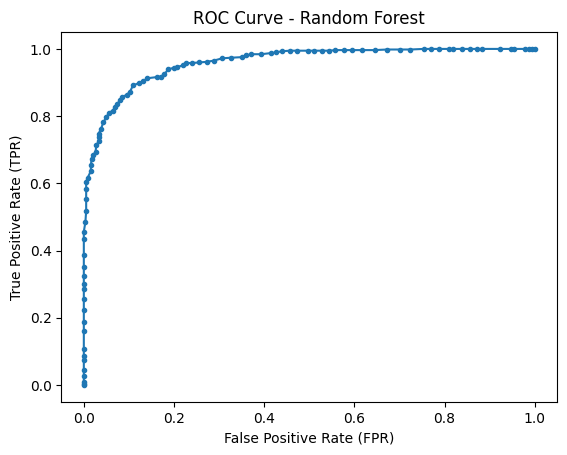

False Positive Rate (FPR): 0.000


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, cross_validate

# Evaluate each model
for name, model in scale_ins_models.items():
    print(f'\n\n--Evaluating {name}--\n')
    
    # Perform cross-validation
    cv_results = cross_validate(
        model, X_train, y_train, cv=5, scoring=['recall', 'roc_auc'], return_train_score=True
    )
    print(f"Cross-Validation Results:\nRecall: {cv_results['test_recall'].mean():.2f}, "
          f"ROC-AUC: {cv_results['test_roc_auc'].mean():.2f} +- {cv_results['test_roc_auc'].std():.3f}\n")

    # Fit the model
    model.fit(X_train, y_train)
    print(f'Score: {model.score(X_test, y_test):.2f}')
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Recall
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    print(f'Training Recall: {train_recall:.2f}')
    print(f'Test Recall: {test_recall:.2f}\n')

    # Classification Report
    report = classification_report(y_test, y_test_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(2)
    print('Classification Report:')
    print(report_df)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # ROC-AUC
    test_roc_auc = roc_auc_score(y_test, y_test_proba)
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    print(f'Test ROC-AUC: {test_roc_auc:.2f}')
    print(f'Train ROC-AUC: {train_roc_auc:.2f}\n')

    # False Positive Rate and True Positive Rate

    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
    plt.plot(fpr, tpr, marker='.')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.show()
    
    # Report specific FPR
    fpr_value = fpr[1] 
    print(f'False Positive Rate (FPR): {fpr_value:.3f}')


XGBoost and Random Forest performs quite well here, with preference given to Random Forest as it has the lower number of false negatives, which is a very important consideration when predicting health outcomes.

Let us consider the winner here, Random Forest. Note its perfect training recall score. This is something to keep in mind as this indicates that it could be overfitting to the training data, however, it appears that its ability to predict on unseen data is still strong, with a test recall of 0.91. Additionally, an ROC-AUC score of 0.94 +- 0.004 in the cross validation further justifies this model as being the best choice.

# Scale Sensitive Models
We will now apply our scale senstive models (KNN, Logistic Regression, SVC)

The StandardScaler is applied to scale the continuous features, since they all use different units to measure different things.



--Evaluating k-Nearest Neighbors--

Cross-Validation Results:
Recall: 0.84, ROC-AUC: 0.85 +- 0.004

Score: 0.79
Training Recall: 0.91
Test Recall: 0.89

Classification Report:
              precision  recall  f1-score  support
0                  0.86    0.69      0.77   577.00
1                  0.74    0.89      0.81   572.00
accuracy           0.79    0.79      0.79     0.79
macro avg          0.80    0.79      0.79  1149.00
weighted avg       0.80    0.79      0.79  1149.00


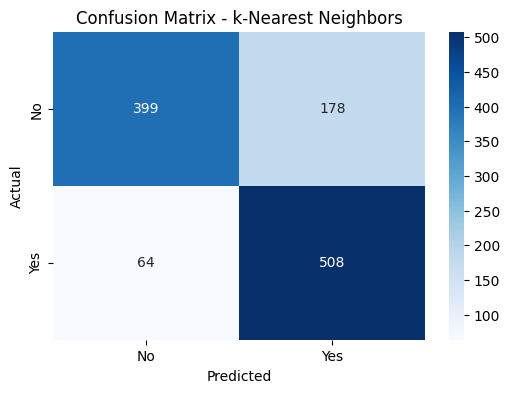

Test ROC-AUC: 0.86
Train ROC-AUC: 0.94



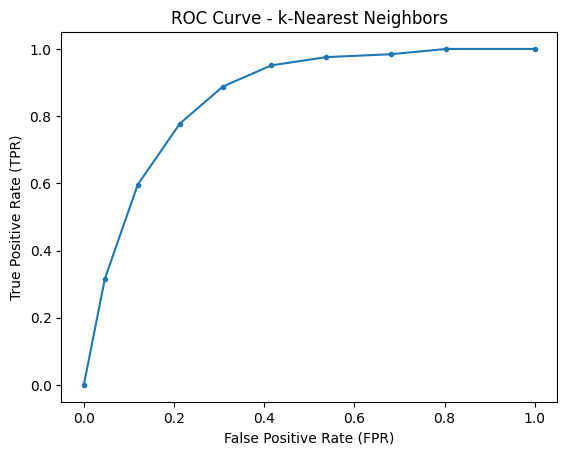

False Positive Rate (FPR): 0.047


--Evaluating Logistic Regression--

Cross-Validation Results:
Recall: 0.71, ROC-AUC: 0.73 +- 0.011

Score: 0.68
Training Recall: 0.71
Test Recall: 0.72

Classification Report:
              precision  recall  f1-score  support
0                  0.70    0.65      0.67   577.00
1                  0.67    0.72      0.69   572.00
accuracy           0.68    0.68      0.68     0.68
macro avg          0.68    0.68      0.68  1149.00
weighted avg       0.68    0.68      0.68  1149.00


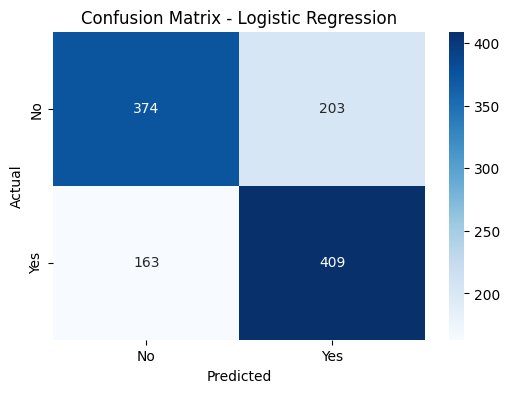

Test ROC-AUC: 0.74
Train ROC-AUC: 0.73



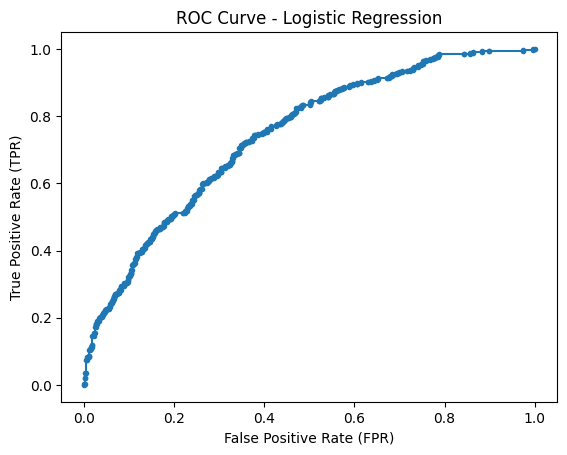

False Positive Rate (FPR): 0.000


--Evaluating SVC--

Cross-Validation Results:
Recall: 0.75, ROC-AUC: 0.79 +- 0.009

Score: 0.72
Training Recall: 0.77
Test Recall: 0.79

Classification Report:
              precision  recall  f1-score  support
0                  0.76    0.66      0.71   577.00
1                  0.70    0.79      0.74   572.00
accuracy           0.72    0.72      0.72     0.72
macro avg          0.73    0.73      0.72  1149.00
weighted avg       0.73    0.72      0.72  1149.00


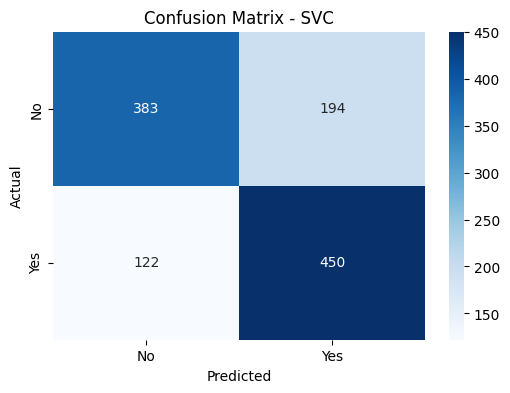

Test ROC-AUC: 0.80
Train ROC-AUC: 0.83



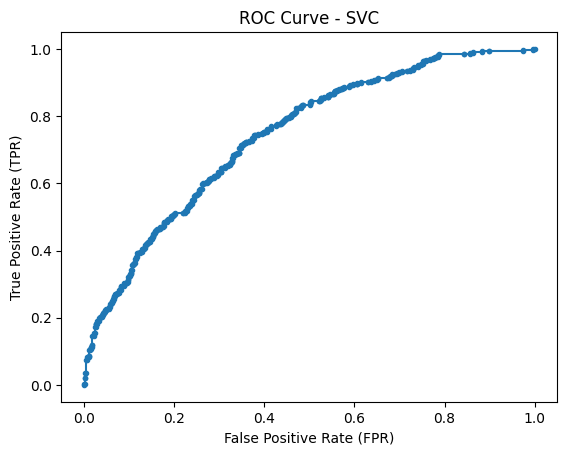

False Positive Rate (FPR): 0.000


In [12]:
from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# List of continuous features
cont_features = ['age', 'cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose', 'MAP']

# Evaluate each model
for name, model in scale_sens_models.items():
    print(f'\n\n--Evaluating {name}--\n')

    # Create the pipeline with a ColumnTransformer to scale continuous features
    preprocessor = ColumnTransformer(
        transformers=[
            ('scaler', StandardScaler(), cont_features)  # Apply StandardScaler to continuous features
        ], 
        remainder='passthrough'  # Leave the non-continuous columns unchanged
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),  # Apply preprocessing (scaling)
        ('model', model)  # Model step
    ])
    
    # Perform cross-validation
    cv_results = cross_validate(
        pipeline, X_train, y_train, cv=5, scoring=['recall', 'roc_auc'], return_train_score=True
    )
    print(f"Cross-Validation Results:\nRecall: {cv_results['test_recall'].mean():.2f}, "
          f"ROC-AUC: {cv_results['test_roc_auc'].mean():.2f} +- {cv_results['test_roc_auc'].std():.3f}\n")

    # Fit the model
    pipeline.fit(X_train, y_train)
    print(f'Score: {pipeline.score(X_test, y_test):.2f}')
    
    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Get probabilities for test/train ROC-AUC calculation
    if name != 'SVC':
        y_train_proba = pipeline.predict_proba(X_train)[:, 1]
        y_test_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        train_decision_values = pipeline.decision_function(X_train)
        test_decision_values = pipeline.decision_function(X_test)

    # Recall
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    print(f'Training Recall: {train_recall:.2f}')
    print(f'Test Recall: {test_recall:.2f}\n')

    # Classification Report
    report = classification_report(y_test, y_test_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(2)
    print('Classification Report:')
    print(report_df)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # ROC-AUC
    if name != 'SVC':
        test_roc_auc = roc_auc_score(y_test, y_test_proba)
        train_roc_auc = roc_auc_score(y_train, y_train_proba)
    else:
        train_roc_auc = roc_auc_score(y_train, train_decision_values)
        test_roc_auc = roc_auc_score(y_test, test_decision_values)
        
    print(f'Test ROC-AUC: {test_roc_auc:.2f}')
    print(f'Train ROC-AUC: {train_roc_auc:.2f}\n')

    # False Positive Rate and True Positive Rate
    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
    plt.plot(fpr, tpr, marker='.')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.show()
    
    # Report specific FPR
    fpr_value = fpr[1]  # Get FPR for the first threshold
    print(f'False Positive Rate (FPR): {fpr_value:.3f}')


It is apparent that these scale-sensitive models perform significantly worse than the tree-based models, despite scaling the numerical values. This could be due to a varity of reasons, likely stemming from the existence of outliers (which are important within a certain boundary that was already imposed), and non-linear relationships.